In [1]:
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "tibetan_pipeline").exists() and (candidate / "requirements.txt").exists():
            return candidate
    raise RuntimeError("Could not find project root containing tibetan_pipeline/ and requirements.txt")

project_root = find_project_root(Path.cwd())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from tibetan_pipeline import TibetanResearchSDK
print(f"project_root={project_root}")


/opt/homebrew/Caskroom/miniconda/base/envs/embedding-tibetan-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0331 23:45:49.568000 23553 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


project_root=/Users/ten-jampa/Documents/personal_projects/embedding-model-for-tibetan-pairwise


In [2]:
sdk = TibetanResearchSDK(
    engine="botok_ours",
    source_format="unicode",
    model_id="buddhist-nlp/gemma-2-mitra-e",
    device="cpu",
    batch_size=1,
)

In [3]:
saraswati_praise_text = """
༄༅། །སྒྲ་དབྱངས་ལྷ་མོ་དབྱངས་ཅན་མ་ལ་བསྟོད་པ།
 
ཨོཾ་བདེ་ལེགས་སུ་གྱུར་ཅིག
 

ཆུ་འཛིན་དཀར་པོའི་གློག་ཕྲེང་དྲ་བ་ཅན། །
མཁའ་ཡི་མཛེས་བྱེད་འདྲ་བའི་ཡིད་འཕྲོག་མ། །
དྲི་ཟའི་ན་ཆུང་དབུས་ན་འཇོ་སྒེག་མཁན། །
རིང་ནས་བརྩེ་བའི་ལྷ་མོ་ད་ཚུར་བྱོན། །
 

པད་མའི་བཞིན་ལ་གཡོ་ལྡན་བུང་བའི་མིག །
མཐོན་མཐིང་རལ་པའི་རྩེ་ན་འོད་དཀར་ཅན། །
རོལ་སྒེག་གར་གྱིས་འགྱིང་བའི་དབྱངས་ཅན་མ། །
ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །
 

རོལ་རྩེད་གར་གྱི་ཉམས་ལྡན་རི་དྭགས་མིག །
མིག་གིས་བལྟ་བས་མི་ངོམ་ཡིད་འཕྲོག་མ། །
མ་ལྟར་བརྩེ་བ་ཁྱེད་ཀྱིས་བདག་གི་ངག །
ངག་དབང་ལྷ་མོ་ཉིད་དང་མཚུངས་པར་མཛོད། །
 

སྟོན་ཟླ་རྒྱས་པའི་དཔལ་ལས་ལྷག་པར་མཛེས། །
ཚངས་དབྱངས་སྙན་པའི་གདངས་ཀྱང་ཟིལ་གྱིས་གནོན། །
ཟབ་ཡངས་རྒྱ་མཚོའི་འཇིང་ལྟར་དཔག་དཀའ་བ། །
དབྱངས་ཅན་ལྷ་མོའི་སྐུ་གསུང་ཐུགས་ལ་འདུད། །
"""

In [5]:
saraswati_praise_text_segmented = sdk.segment_text(saraswati_praise_text)
for segment in saraswati_praise_text_segmented.segments:
    print(segment)


༄༅། །སྒྲ་དབྱངས་ལྷ་མོ་དབྱངས་ཅན་མ་ལ་བསྟོད་པ།
ཨོཾ་བདེ་ལེགས་སུ་གྱུར་ཅིག ཆུ་འཛིན་དཀར་པོའི་གློག་ཕྲེང་དྲ་བ་ཅན། །
མཁའ་ཡི་མཛེས་བྱེད་འདྲ་བའི་ཡིད་འཕྲོག་མ། །
དྲི་ཟའི་ན་ཆུང་དབུས་ན་འཇོ་སྒེག་མཁན། །
རིང་ནས་བརྩེ་བའི་ལྷ་མོ་ད་ཚུར་བྱོན། །
པད་མའི་བཞིན་ལ་གཡོ་ལྡན་བུང་བའི་མིག །
མཐོན་མཐིང་རལ་པའི་རྩེ་ན་འོད་དཀར་ཅན། །
རོལ་སྒེག་གར་གྱིས་འགྱིང་བའི་དབྱངས་ཅན་མ། །
ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །
རོལ་རྩེད་གར་གྱི་ཉམས་ལྡན་རི་དྭགས་མིག །
མིག་གིས་བལྟ་བས་མི་ངོམ་ཡིད་འཕྲོག་མ། །
མ་ལྟར་བརྩེ་བ་ཁྱེད་ཀྱིས་བདག་གི་ངག །
ངག་དབང་ལྷ་མོ་ཉིད་དང་མཚུངས་པར་མཛོད། །
སྟོན་ཟླ་རྒྱས་པའི་དཔལ་ལས་ལྷག་པར་མཛེས། །
ཚངས་དབྱངས་སྙན་པའི་གདངས་ཀྱང་ཟིལ་གྱིས་གནོན། །
ཟབ་ཡངས་རྒྱ་མཚོའི་འཇིང་ལྟར་དཔག་དཀའ་བ། །
དབྱངས་ཅན་ལྷ་མོའི་སྐུ་གསུང་ཐུགས་ལ་འདུད། །


In [4]:
foundation_of_all_good_qualities_text = """
༄༅། །ཡོན་ཏན་གཞིར་གྱུར་མ་བཞུགས་སོ། །
 

ཡོན་ཏན་ཀུན་གྱི་གཞིར་གྱུར་དྲིན་ཅན་རྗེ། །
ཚུལ་བཞིན་བསྟེན་པ་ལམ་གྱི་རྩ་བ་རུ། །
ལེགས་པར་མཐོང་ནས་འབད་པ་དུ་མ་ཡིས། །
གུས་པ་ཆེན་པོས་བསྟེན་པར་བྱིན་གྱིས་རློབས། །
 

ལན་ཅིག་རྙེད་པའི་དལ་བའི་རྟེན་བཟང་འདི། །
ཤིན་ཏུ་རྙེད་དཀའ་དོན་ཆེ་ཤེས་གྱུར་ནས། །
ཉིན་མཚན་ཀུན་ཏུ་སྙིང་པོ་ལེན་པའི་བློ། །
རྒྱུན་ཆད་མེད་པར་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །
 

ལུས་སྲོག་གཡོ་བ་ཆུ་ཡི་ཆུ་བུར་བཞིན། །
མྱུར་དུ་འཇིག་པའི་འཆི་བ་དྲན་པ་དང༌། །
ཤི་བའི་རྗེས་སུ་ལུས་དང་གྲིབ་མ་བཞིན། །
དཀར་ནག་ལས་འབྲས་ཕྱི་བཞིན་འབྲང་བ་ལ། །
 

ངེས་པ་བརྟན་པོ་རྙེད་ནས་ཉེས་པའི་ཚོགས། །
ཕྲ་ཞིང་ཕྲ་བ་རྣམས་ཀྱང་སྤོང་བ་དང༌། །
དགེ་ཚོགས་མཐའ་དག་སྒྲུབ་པར་བྱེད་པ་ལ། །
རྟག་ཏུ་བག་དང་ལྡན་པར་བྱིན་གྱིས་རློབས། །
 

སྤྱད་པས་མི་ངོམས་སྡུག་བསྔལ་ཀུན་གྱི་སྒོ། །
ཡིད་བརྟན་མི་རུང་སྲིད་པའི་ཕུན་ཚོགས་ཀྱི། །
ཉེས་དམིགས་རིག་ནས་ཐར་བའི་བདེ་བ་ལ། །
དོན་གཉེར་ཆེན་པོ་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །
 

རྣམ་དག་བསམ་པ་དེ་ཡིས་དྲངས་པ་ཡི། །
དྲན་དང་ཤེས་བཞིན་བག་ཡོད་ཆེན་པོ་ཡིས། །
བསྟན་པའི་རྩ་བ་སོ་སོར་ཐར་བ་ལ། །
སྒྲུབ་པ་སྙིང་པོར་བྱེད་པར་བྱིན་གྱིས་རློབས། །
 

རང་ཉིད་སྲིད་མཚོར་ལྷུང་བ་ཇི་བཞིན་དུ། །
མར་གྱུར་འགྲོ་བ་ཀུན་ཀྱང་དེ་འདྲ་བར། །
མཐོང་ནས་འགྲོ་བ་སྒྲོལ་བའི་ཁུར་འཁྱེར་བའི། །
བྱང་ཆུབ་སེམས་མཆོག་འབྱོངས་པར་བྱིན་གྱིས་རློབས། །
 

སེམས་ཙམ་བསྐྱེད་ཀྱང་ཚུལ་ཁྲིམས་རྣམ་གསུམ་ལ། །
གོམས་པ་མེད་ན་བྱང་ཆུབ་མི་འགྲུབ་པར། །
ལེགས་པར་མཐོང་ནས་རྒྱལ་སྲས་སྡོམ་པ་ལ། །
བརྩོན་པ་དྲག་པོས་སློབ་པར་བྱིན་གྱིས་རློབས། །
 

ལོག་པའི་ཡུལ་ལ་གཡེངས་པ་ཞི་བྱེད་ཅིང༌། །
ཡང་དག་དོན་ལ་ཚུལ་བཞིན་དཔྱོད་པ་ཡིས། །
ཞི་གནས་ལྷག་མཐོང་ཟུང་དུ་འབྲེལ་བའི་ལམ། །
མྱུར་དུ་རྒྱུད་ལ་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །
 

ཐུན་མོང་ལམ་སྦྱང་སྣོད་དུ་གྱུར་པ་ན། །
ཐེག་པ་ཀུན་གྱི་མཆོག་གྱུར་རྡོ་རྗེ་ཐེག།
སྐལ་བཟང་སྐྱེ་བོའི་འཇུག་ངོགས་དམ་པ་དེར། །
བདེ་བླག་ཉིད་དུ་འཇུག་པར་བྱིན་གྱིས་རློབས། །
 

དེ་ཚེ་དངོས་གྲུབ་རྣམ་གཉིས་སྒྲུབ་པའི་གཞི། །
རྣམ་དག་དམ་ཚིག་སྡོམ་པར་གསུངས་པ་ལ། །
བཅོས་མ་མིན་པའི་ངེས་པ་རྙེད་གྱུར་ནས། །
སྲོག་དང་བསྡོས་ཏེ་སྲུང་བར་བྱིན་གྱིས་རློབས། །
 

དེ་ནས་རྒྱུད་སྡེ་སྙིང་པོ་རིམ་གཉིས་ཀྱི། །
གནད་རྣམས་ཇི་བཞིན་རྟོགས་ནས་བརྩོན་པ་ཡིས། །
ཐུན་བཞིའི་རྣལ་འབྱོར་སྤྱོད་ལས་མི་གཡེལ་བར། །
དམ་པའི་གསུང་བཞིན་སྒྲུབ་པར་བྱིན་གྱིས་རློབས། །
 

དེ་ལྟར་ལམ་བཟང་སྟོན་པའི་བཤེས་གཉེན་དང༌། །
ཚུལ་བཞིན་སྒྲུབ་པའི་གྲོགས་རྣམས་ཞབས་བརྟན་ཅིང༌། །
ཕྱི་དང་ནང་གི་བར་དུ་གཅོད་པའི་ཚོགས། །
ཉེ་བར་ཞི་བར་བྱིན་གྱིས་བརླབ་ཏུ་གསོལ། །
 

སྐྱེ་བ་ཀུན་ཏུ་ཡང་དག་བླ་མ་དང་། །
འབྲལ་མེད་ཆོས་ཀྱི་དཔལ་ལ་ལོངས་སྤྱོད་ཅིང་། །
ས་དང་ལམ་གྱི་ཡོན་ཏན་རབ་རྫོགས་ནས། །
རྡོ་རྗེ་འཆང་གི་གོ་འཕང་མྱུར་ཐོབ་ཤོག །
 

ཅེས་པ་འདི་ནི་རྗེ་ཙོང་ཁ་པ་བློ་བཟང་གྲགས་པས་མཛད་པའོ། །
"""

In [6]:
foundation_of_all_good_qualities_text_segments = sdk.segment_text(
    foundation_of_all_good_qualities_text
)
foundation_of_all_good_qualities_text_segments.to_dataframe().head()

,segment_index,start,end,segment_text
0,0,0,36,༄༅། །ཡོན་ཏན་གཞིར་གྱུར་མ་བཞུགས་སོ། །
1,1,36,76,ཡོན་ཏན་ཀུན་གྱི་གཞིར་གྱུར་དྲིན་ཅན་རྗེ། །
2,2,76,111,ཚུལ་བཞིན་བསྟེན་པ་ལམ་གྱི་རྩ་བ་རུ། །
3,3,111,145,ལེགས་པར་མཐོང་ནས་འབད་པ་དུ་མ་ཡིས། །
4,4,145,187,གུས་པ་ཆེན་པོས་བསྟེན་པར་བྱིན་གྱིས་རློབས། །


In [8]:
import requests
import numpy as np

def get_embedding(text, is_query=False, target_lang="Tibetan"):
    if is_query:
        text = f"<instruct>Please find the semantically most similar text in {target_lang}.\n<query>{text}"
    
    resp = requests.post(
        "http://localhost:8080/v1/embeddings",  #quantised model: https://huggingface.co/mradermacher/gemma-2-mitra-e-i1-GGUF (Q6_K)
        json={"input": text, "model": "gemma-2-mitra-e"}
    )
    return np.array(resp.json()["data"][0]["embedding"])

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


In [12]:
saraswati_praise_embeddings = [get_embedding(segment) for segment in saraswati_praise_text_segmented.segments]
foundation_of_all_good_qualities_embeddings = [get_embedding(segment) for segment in foundation_of_all_good_qualities_text_segments.segments]

In [24]:
import pandas as pd

# Generic: compute cosine similarity between two embedding sets (matrices) of possibly different length
def compute_pairwise_similarity_matrix(embeddings_a, embeddings_b):
    """
    embeddings_a: List or np.array, shape (n_a, dim)
    embeddings_b: List or np.array, shape (n_b, dim)
    Returns:
        similarity_matrix: np.array of shape (n_a, n_b), where element (i, j) is cosine_sim(a_i, b_j)
    """
    a = np.vstack(embeddings_a)
    b = np.vstack(embeddings_b)
    # Normalize
    a_norm = a / np.linalg.norm(a, axis=1, keepdims=True)
    b_norm = b / np.linalg.norm(b, axis=1, keepdims=True)
    # Compute similarity
    similarity_matrix = np.dot(a_norm, b_norm.T)
    return similarity_matrix

# Compute pairwise similarity between saraswati_praise_embeddings and foundation_of_all_good_qualities_embeddings
similarity_matrix = compute_pairwise_similarity_matrix(
    saraswati_praise_embeddings, foundation_of_all_good_qualities_embeddings
)

# Be explicit: "a" refers to saraswati_praise, "b" to foundation_of_all_good_qualities
segment_indices_a = saraswati_praise_text_segmented.to_dataframe()['segment_index']
segment_indices_b = foundation_of_all_good_qualities_text_segments.to_dataframe()['segment_index']

# DataFrame shape must align: index from saraswati_praise, columns from foundation_of_all_good_qualities
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=segment_indices_a,
    columns=segment_indices_b
)

similarity_df.head()  # Show the similarity matrix between the two texts

segment_index,0,1,2,3,4,5,6,7,8,9,...,41,42,43,44,45,46,47,48,49,50
segment_index,,,,,,,,,,,,,,,,,,,,,
0,0.389108,0.328265,0.269352,0.283297,0.328463,0.264406,0.241145,0.314533,0.246351,0.219652,...,0.279413,0.229270,0.218150,0.364474,0.240955,0.299355,0.270945,0.320751,0.324276,0.404174
1,0.386863,0.459640,0.302127,0.388078,0.431651,0.371132,0.323441,0.452305,0.372613,0.347319,...,0.304004,0.275500,0.308307,0.418034,0.373189,0.401332,0.389481,0.435286,0.466537,0.377009
2,0.362678,0.403463,0.299692,0.327702,0.353401,0.331575,0.324026,0.330357,0.375762,0.341543,...,0.283415,0.279345,0.324755,0.331958,0.339268,0.285125,0.329391,0.324582,0.358191,0.364397
3,0.329367,0.346969,0.321627,0.320773,0.339223,0.291275,0.280875,0.329141,0.316720,0.240911,...,0.310099,0.330192,0.344956,0.300479,0.352357,0.333297,0.365098,0.301475,0.331935,0.352892
4,0.406017,0.435178,0.371161,0.375021,0.512700,0.352509,0.323137,0.433591,0.331277,0.299475,...,0.328116,0.303209,0.357210,0.399489,0.376379,0.385240,0.315580,0.452572,0.360872,0.337826


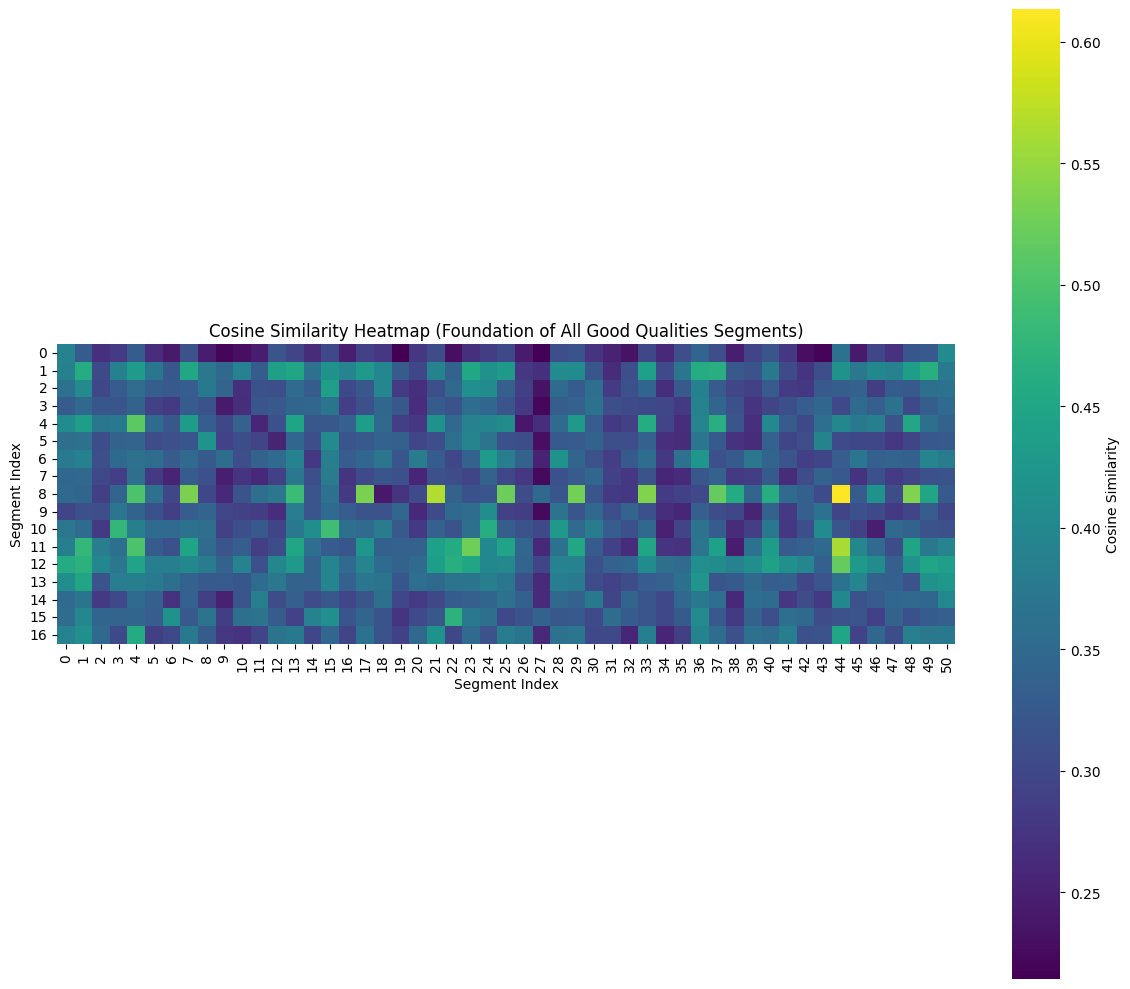

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(similarity_df, cmap='viridis', square=True, cbar_kws={'label': 'Cosine Similarity'})
plt.title('Cosine Similarity Heatmap (Foundation of All Good Qualities Segments)')
plt.xlabel('Segment Index')
plt.ylabel('Segment Index')
plt.tight_layout()
plt.show()

In [28]:
def get_top_n_similar_pairs(
    similarity_df: pd.DataFrame,
    text_a,
    text_b,
    n: int = 5,
    return_sentences: bool = True
):
    """
    Given a similarity DataFrame between segments (square, symmetric),
    and the two segment objects (text_a, text_b),
    return the top n most similar segment pairs as a list of dicts (with segment texts if return_sentences is True):
    [
        {
            'segment_index_1': idx1,
            'segment_index_2': idx2,
            'similarity': sim,
            'segment_text_1': ...,
            'segment_text_2': ...,
        },
        ...
    ]
    Only off-diagonal pairs are considered (i != j), unless self-similarity is desired.
    """
    # Flatten the upper triangle (excluding diagonal)
    tril_idx = np.tril_indices_from(similarity_df, k=-1)
    records = []
    for i, j in zip(*tril_idx):
        sim = similarity_df.values[i, j]
        idx1 = similarity_df.index[i]
        idx2 = similarity_df.columns[j]
        record = {
            'segment_index_1': idx1,
            'segment_index_2': idx2,
            'similarity': sim,
        }
        if return_sentences:
            segment_text_1 = text_a.segments[i] if hasattr(text_a, "segments") else None
            segment_text_2 = text_b.segments[j] if hasattr(text_b, "segments") else None
            record['segment_text_1'] = segment_text_1
            record['segment_text_2'] = segment_text_2
        records.append(record)

    # Sort records by descending similarity
    records_sorted = sorted(records, key=lambda d: d['similarity'], reverse=True)
    return records_sorted[:n]

top_10_pairs = get_top_n_similar_pairs(
    similarity_df,
    saraswati_praise_text_segmented,
    foundation_of_all_good_qualities_text_segments,
    n=10,
    return_sentences=True,
)
top_10_pairs


[{'segment_index_1': np.int64(8),
  'segment_index_2': np.int64(7),
  'similarity': np.float64(0.532491342460937),
  'segment_text_1': 'ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །',
  'segment_text_2': 'རྒྱུན་ཆད་མེད་པར་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །'},
 {'segment_index_1': np.int64(8),
  'segment_index_2': np.int64(4),
  'similarity': np.float64(0.5011734039335028),
  'segment_text_1': 'ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །',
  'segment_text_2': 'གུས་པ་ཆེན་པོས་བསྟེན་པར་བྱིན་གྱིས་རློབས། །'},
 {'segment_index_1': np.int64(11),
  'segment_index_2': np.int64(4),
  'similarity': np.float64(0.49988524032402754),
  'segment_text_1': 'མ་ལྟར་བརྩེ་བ་ཁྱེད་ཀྱིས་བདག་གི་ངག །',
  'segment_text_2': 'གུས་པ་ཆེན་པོས་བསྟེན་པར་བྱིན་གྱིས་རློབས། །'},
 {'segment_index_1': np.int64(11),
  'segment_index_2': np.int64(1),
  'similarity': np.float64(0.47997016870080533),
  'segment_text_1': 'མ་ལྟར་བརྩེ་བ་ཁྱེད་ཀྱིས་བདག་གི་ངག །',
  'segment_text_2': 'ཡོན་ཏན་ཀུན་གྱི་གཞིར་གྱུར་དྲིན་ཅན་རྗེ། །'},
 {'segment_index_1': np.int64(10),
 